<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/BeefMicrobialPopulationPrediction-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electronic Nose Project
## Beef Microbial Population Prediction
(c)2024 Djoko Purwanto, Dept. of Electrical Engineering <br>
Institut Teknologi Sepuluh Nopember (ITS) <br>
djoko@its.ac.id

In [3]:
import platform
import psutil
import tensorflow as tf
from datetime import datetime

def get_system_info():
    info = {}
    # Get system information
    info['platform'] = platform.system()
    info['platform-version'] = platform.version()
    info['architecture'] = platform.machine()
    info['hostname'] = platform.node()
    info['processor'] = platform.processor()
    info['ram'] = str(round(psutil.virtual_memory().total / (1024.0 **3))) + ' GB'
    return info

print(f'Program start ...')
# Print the system information
system_info = get_system_info()
for key, value in system_info.items():
    print(f'{key}: {value}')

# Print TensorFlow version
print(f'TensorFlow version: {tf.__version__}')
if tf.config.list_physical_devices('GPU'):
    print(f'GPU is being used by TensorFlow')
else: print(f'GPU is unavailable for TensorFlow')

# Get the current time
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
# Print the current time
print(f'The current time is: {current_time}')

Program start ...
platform: Linux
platform-version: #1 SMP Mon Feb  2 12:27:57 UTC 2026
architecture: x86_64
hostname: 07251c383370
processor: x86_64
ram: 13 GB
TensorFlow version: 2.20.0
GPU is unavailable for TensorFlow
The current time is: 2026-05-07 12:09:00


### (1) Read and Visualize Data

In [4]:
import pandas as pd

df_sheets = pd.read_excel('e-nose_dataset_12_beef_cuts.xlsx',
    sheet_name=['1.Inside-Outside', '2.Round','3.Top_Sirloin'])
df_sheets['1.Inside-Outside']

,Minute,TVC,Label,MQ135,MQ136,MQ137,MQ138,MQ2,MQ3,MQ4,MQ5,MQ6,MQ8,MQ9
0,1,2.002220,1,17.85,15.58,7.95,21.23,16.52,24.07,12.29,9.02,14.26,40.29,14.40
1,2,2.002220,1,18.00,15.84,8.11,21.43,16.80,24.18,12.59,9.13,14.38,40.80,14.52
2,3,2.002220,1,17.70,15.26,8.01,21.04,15.85,23.96,12.24,9.34,14.26,39.79,14.17
3,4,2.002220,1,17.78,15.51,8.01,21.23,16.32,23.62,12.39,8.95,14.26,40.54,14.11
4,5,2.002220,1,17.70,15.32,7.98,21.14,16.05,23.73,12.39,9.02,14.20,40.04,14.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2215,2216,5.619733,4,11.99,6.16,21.69,11.22,6.35,14.95,4.22,20.42,17.67,30.90,10.70
2216,2217,5.619733,4,12.13,6.16,21.79,11.22,6.35,14.95,4.24,20.15,17.67,34.71,10.49
2217,2218,5.619733,4,11.99,6.16,21.69,11.17,6.35,14.95,4.22,20.15,17.75,34.12,10.74
2218,2219,5.619733,4,11.94,6.11,21.69,11.13,6.32,14.89,4.20,20.42,17.58,33.17,10.57


In [5]:
print(df_sheets['2.Round'].head(),'\n')
print(df_sheets['3.Top_Sirloin'].head())

   Minute      TVC  Label  MQ135  MQ136  MQ137  MQ138    MQ2    MQ3    MQ4  \
0       1  1.87589      1  14.87  37.65   5.16  20.37  12.25  16.24  28.66   
1       2  1.87589      1  14.94  38.56   5.09  20.46  13.37  16.38  28.50   
2       3  1.87589      1  15.00  39.50   5.07  20.46  12.40  17.01  28.18   
3       4  1.87589      1  14.87  40.48   5.05  20.37  12.50  16.44  28.18   
4       5  1.87589      1  14.87  40.73   5.00  20.27  12.01  16.38  28.50   

    MQ5   MQ6    MQ8    MQ9  
0  6.11  3.59  46.19  10.01  
1  5.74  3.39  46.19  10.05  
2  6.18  3.25  46.83  10.21  
3  5.60  3.16  46.19  10.13  
4  5.48  3.11  47.48  10.13   

   Minute      TVC  Label  MQ135  MQ136  MQ137  MQ138    MQ2    MQ3    MQ4  \
0       1  1.87589      1  18.47  13.52  10.06  18.77  19.94  26.92  11.34   
1       2  1.87589      1  18.47  13.52  10.10  18.86  19.85  26.92  11.71   
2       3  1.87589      1  18.47  13.52  10.14  18.77  20.03  27.06  11.47   
3       4  1.87589      1  18.55  13.

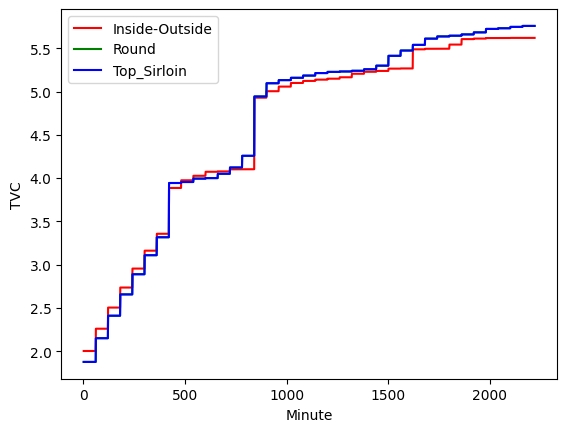

In [6]:
import matplotlib.pyplot as plt

minute_1 = df_sheets['1.Inside-Outside']['Minute'].values
minute_2 = df_sheets['2.Round']['Minute'].values
minute_3 = df_sheets['3.Top_Sirloin']['Minute'].values
tvc_1 = df_sheets['1.Inside-Outside']['TVC'].values
tvc_2 = df_sheets['2.Round']['TVC'].values
tvc_3 = df_sheets['3.Top_Sirloin']['TVC'].values

plt.figure()
plt.plot(minute_1,tvc_1,'r-',minute_2,tvc_2,'g-',minute_3,tvc_3,'b-')
plt.legend(['Inside-Outside','Round','Top_Sirloin']); plt.xlabel('Minute'); plt.ylabel('TVC');

### (2) Create Dataset

In [7]:
df_dataset = pd.DataFrame()
df_dataset = df_sheets['1.Inside-Outside'].copy()
df_dataset.drop(columns=['Minute', 'Label'], inplace=True)
df_dataset.head()

,TVC,MQ135,MQ136,MQ137,MQ138,MQ2,MQ3,MQ4,MQ5,MQ6,MQ8,MQ9
0,2.00222,17.85,15.58,7.95,21.23,16.52,24.07,12.29,9.02,14.26,40.29,14.40
1,2.00222,18.00,15.84,8.11,21.43,16.80,24.18,12.59,9.13,14.38,40.80,14.52
2,2.00222,17.70,15.26,8.01,21.04,15.85,23.96,12.24,9.34,14.26,39.79,14.17
3,2.00222,17.78,15.51,8.01,21.23,16.32,23.62,12.39,8.95,14.26,40.54,14.11
4,2.00222,17.70,15.32,7.98,21.14,16.05,23.73,12.39,9.02,14.20,40.04,14.06


In [8]:
ds_values = df_dataset.values

ds_inputs = ds_values[:,1:]
ds_outputs = ds_values[:,0:1]

print(f'input shape  : {ds_inputs.shape}')
print(f'output shape : {ds_outputs.shape}')
print(ds_inputs[0:5,:])
print(ds_outputs[0:5,:])

input shape  : (2220, 11)
output shape : (2220, 1)
[[17.85 15.58  7.95 21.23 16.52 24.07 12.29  9.02 14.26 40.29 14.4 ]
 [18.   15.84  8.11 21.43 16.8  24.18 12.59  9.13 14.38 40.8  14.52]
 [17.7  15.26  8.01 21.04 15.85 23.96 12.24  9.34 14.26 39.79 14.17]
 [17.78 15.51  8.01 21.23 16.32 23.62 12.39  8.95 14.26 40.54 14.11]
 [17.7  15.32  7.98 21.14 16.05 23.73 12.39  9.02 14.2  40.04 14.06]]
[[2.00222]
 [2.00222]
 [2.00222]
 [2.00222]
 [2.00222]]


#### Input normalization

In [9]:
import numpy as np

inp_min = np.min(ds_inputs); inp_max = np.max(ds_inputs)
print(f'inputs values --> min = {inp_min}; max = {inp_max}')

inputs values --> min = 3.72; max = 46.51


Set new input min and input max, then do input normalization

In [10]:
def normalization(x,xmin,xmax):
    return 2*(x-xmin)/(xmax-xmin) - 1

inp_min, inp_max = 0.0, 50.0
ds_inputs_norm = normalization(ds_inputs, inp_min, inp_max)

print(f'input normalization shape: {ds_inputs_norm.shape}')
print(ds_inputs_norm[0:5,:])

input normalization shape: (2220, 11)
[[-0.286  -0.3768 -0.682  -0.1508 -0.3392 -0.0372 -0.5084 -0.6392 -0.4296
   0.6116 -0.424 ]
 [-0.28   -0.3664 -0.6756 -0.1428 -0.328  -0.0328 -0.4964 -0.6348 -0.4248
   0.632  -0.4192]
 [-0.292  -0.3896 -0.6796 -0.1584 -0.366  -0.0416 -0.5104 -0.6264 -0.4296
   0.5916 -0.4332]
 [-0.2888 -0.3796 -0.6796 -0.1508 -0.3472 -0.0552 -0.5044 -0.642  -0.4296
   0.6216 -0.4356]
 [-0.292  -0.3872 -0.6808 -0.1544 -0.358  -0.0508 -0.5044 -0.6392 -0.432
   0.6016 -0.4376]]


#### Split dataset into 80% train and 20% test set

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(ds_inputs_norm, ds_outputs, test_size=0.2, random_state=42)

print(f'Train set shape: {X_train.shape}')
print(f'Test set shape : {X_test.shape}')

Train set shape: (1776, 11)
Test set shape : (444, 11)


### (3) Build Model

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(20, activation='sigmoid',input_dim=X_train.shape[1]),
    tf.keras.layers.Dense(1)])

model.summary()
print('Model created')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

Model created


### (4) Train model

In [ ]:
import time
import datetime

epochs = 5000
batch_size = int(0.1*len(X_train))
print('Batch size: ',batch_size)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_mse', factor=0.1, patience=50, min_lr=1e-6)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='mse', patience=75, restore_best_weights=True)

optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-2)
model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mse'])

starttime = time.time()

model_history = model.fit(X_train,Y_train, epochs=epochs,
    validation_data=(X_test, Y_test), verbose=2, batch_size=batch_size,
    callbacks=[reduce_lr, early_stopping] )

stoptime =  time.time()-starttime
trainingtime = datetime.timedelta(seconds=stoptime)
print(f'\nTraining time : {trainingtime}')
print('End of training')

Batch size:  177
Epoch 1/5000
11/11 - 1s - 107ms/step - loss: 15.8674 - mse: 15.8674 - val_loss: 8.1438 - val_mse: 8.1438 - learning_rate: 0.0100
Epoch 2/5000
11/11 - 0s - 10ms/step - loss: 5.1531 - mse: 5.1531 - val_loss: 2.2754 - val_mse: 2.2754 - learning_rate: 0.0100
Epoch 3/5000
11/11 - 0s - 9ms/step - loss: 1.5740 - mse: 1.5740 - val_loss: 1.2455 - val_mse: 1.2455 - learning_rate: 0.0100
Epoch 4/5000
11/11 - 0s - 9ms/step - loss: 1.2272 - mse: 1.2272 - val_loss: 1.3598 - val_mse: 1.3598 - learning_rate: 0.0100
Epoch 5/5000
11/11 - 0s - 10ms/step - loss: 1.2813 - mse: 1.2813 - val_loss: 1.2955 - val_mse: 1.2955 - learning_rate: 0.0100
Epoch 6/5000
11/11 - 0s - 9ms/step - loss: 1.1923 - mse: 1.1923 - val_loss: 1.2022 - val_mse: 1.2022 - learning_rate: 0.0100
Epoch 7/5000
11/11 - 0s - 10ms/step - loss: 1.1267 - mse: 1.1267 - val_loss: 1.1722 - val_mse: 1.1722 - learning_rate: 0.0100
Epoch 8/5000
11/11 - 0s - 10ms/step - loss: 1.1132 - mse: 1.1132 - val_loss: 1.1523 - val_mse: 1.1523

### (5) Performance Evaluation
#### Training

In [ ]:
plt.figure(figsize=[6, 4])
plt.plot(model_history.history['loss'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_loss'], 'b', linewidth=1.0)
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs ', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss Curves', fontsize=14)
plt.show()

plt.figure(figsize=[6, 4])
plt.plot(model_history.history['mse'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_mse'], 'b', linewidth=1.0)
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs ', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('MSE Curves', fontsize=14)
plt.show()

plt.figure(figsize=[6, 4])
plt.plot(model_history.history['learning_rate'], 'g', linewidth=1.0)
plt.xlabel('Epochs ', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Curve', fontsize=14)
plt.show()

#### Model output

In [ ]:
Pred_test = model.predict(X_test)
plt.figure()
plt.plot(Y_test,Y_test,'b-',Y_test,Pred_test,'ro')
plt.legend(['True','Predicted']); plt.xlabel('Output'); plt.ylabel('Output');

### (6) Explore the Model
Model weights and biases

In [ ]:
dense_layer1 = model.layers[0]
weights1, biases1 = dense_layer1.get_weights()
print(f'Weights_1 shape: {weights1.shape}')
print(f'Biases_1 shape: {biases1.shape}')
print(f'Weights_1:\n {weights1}')
print(f'Biases_1 :\n {biases1}')

dense_layer2 = model.layers[1]
weights2, biases2 = dense_layer2.get_weights()
print(f'Weights_2 shape: {weights2.shape}')
print(f'Biases_2 shape: {biases2.shape}')
print(f'Weights_2:\n {weights2}')
print(f'Biases_2 :\n {biases2}')

Save the model

In [ ]:
model_filename = 'BMPPmodelTF'+tf.__version__+'.keras'

model.save(model_filename)
print(f'Model saved as {model_filename}')

print(f'End of program... ')